In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math

In [2]:
batch_size = 8
seq_len = 128
embed_dim = 768
num_heads = 12
head_dim = embed_dim // num_heads

x = torch.randn(batch_size, seq_len, embed_dim)
print(f"Input tensor :{x.shape}")

x_heads = x.view(batch_size, seq_len, num_heads, head_dim)
print(f"splitting the tensor heads: {x_heads.shape}")

x_ready = x_heads.permute(0, 2, 1, 3)
print(f"permutting for attention: {x_ready.shape}")

Input tensor :torch.Size([8, 128, 768])
splitting the tensor heads: torch.Size([8, 128, 12, 64])
permutting for attention: torch.Size([8, 12, 128, 64])


In [3]:
v = torch.tensor([1., 0.])

rotate_90 = torch.tensor([
    [0., -1.], 
    [1., 0.]
])

rotated_90 = rotate_90 @ v
print(f"rotated by 90 deg: {rotated_90.tolist()}")

angle = math.radians(45)
rotate_45 = torch.tensor([
    [math.cos(angle), -math.sin(angle)], 
    [math.sin(angle), -math.cos(angle)]
])

rotated_45 = rotate_45 @ v
print(f"rotated by 45 deg: [{rotated_45[0]:.3f}, {rotated_45[1]:.3f}]")

rotated by 90 deg: [0.0, 1.0]
rotated by 45 deg: [0.707, 0.707]


In [4]:
def plot_transformation(matrix, title="Transformation"):
    """Visualize how a 2x2 matrix transforms a grid of points."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Create a grid of points
    n = 10
    x = np.linspace(-2, 2, n)
    y = np.linspace(-2, 2, n)

    # Plot original grid
    ax = axes[0]
    ax.set_title("Original", fontsize=14, fontweight='bold')
    for xi in x:
        ax.plot([xi]*n, y, 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        ax.plot(x, [yi]*n, 'b-', alpha=0.3, linewidth=1)

    # Highlight a square
    square_x = [0, 1, 1, 0, 0]
    square_y = [0, 0, 1, 1, 0]
    ax.plot(square_x, square_y, 'r-', linewidth=3)

    # Arrow for basis vectors
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # Plot transformed grid
    M = np.array(matrix)
    ax = axes[1]
    ax.set_title(f"{title}", fontsize=14, fontweight='bold')

    for xi in x:
        points = np.array([[xi, yi] for yi in y])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        points = np.array([[xi, yi] for xi in x])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)

    # Transform the square
    sq = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    sq_t = M @ sq
    ax.plot(sq_t[0], sq_t[1], 'r-', linewidth=3)

    # Transform basis vectors
    e1_t = M @ np.array([1, 0])
    e2_t = M @ np.array([0, 1])
    ax.annotate('', xy=e1_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=e2_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()

print("✅ Visualization function ready! Run the cells below.")

✅ Visualization function ready! Run the cells below.


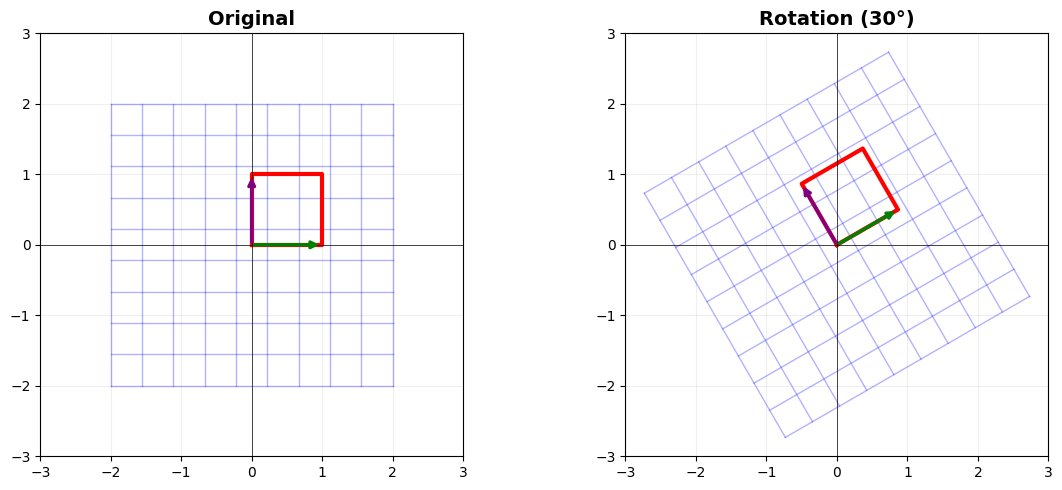

In [5]:
# 🔥 ROTATION — the grid spins!
angle = math.radians(30)
rotation = [[math.cos(angle), -math.sin(angle)],
            [math.sin(angle),  math.cos(angle)]]
plot_transformation(rotation, "Rotation (30°)")

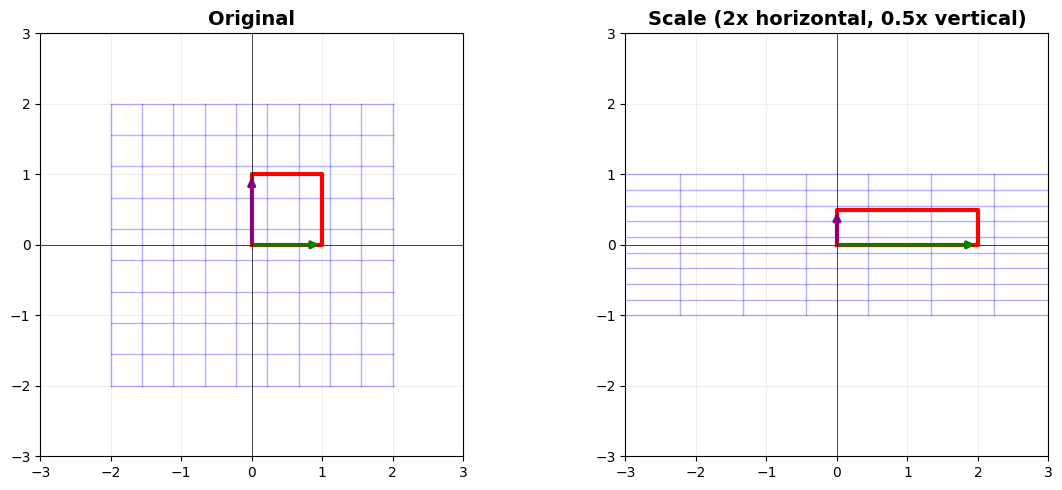

In [6]:
# 🔥 SCALING — stretch and squish!
plot_transformation([[2, 0], [0, 0.5]], "Scale (2x horizontal, 0.5x vertical)")

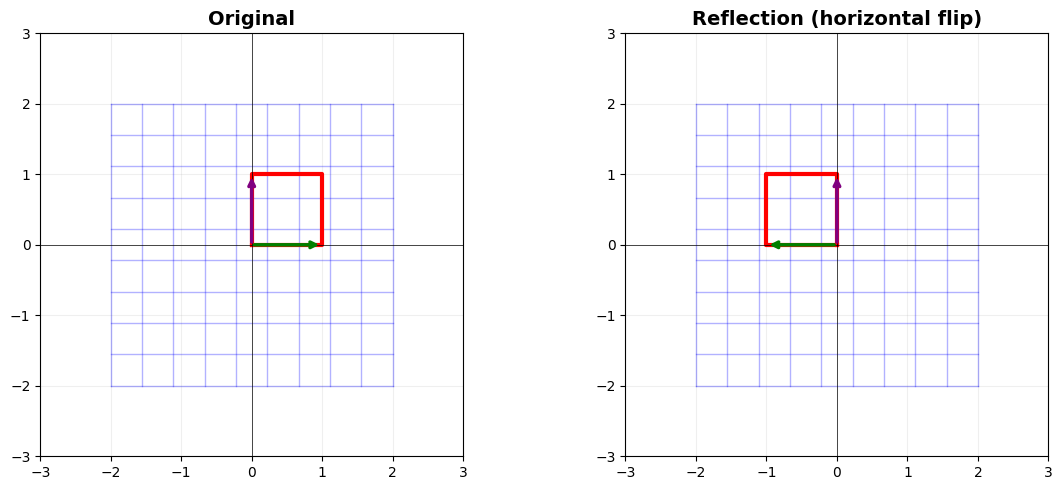

In [7]:
# 🔥 REFLECTION — flip it!
plot_transformation([[-1, 0], [0, 1]], "Reflection (horizontal flip)")

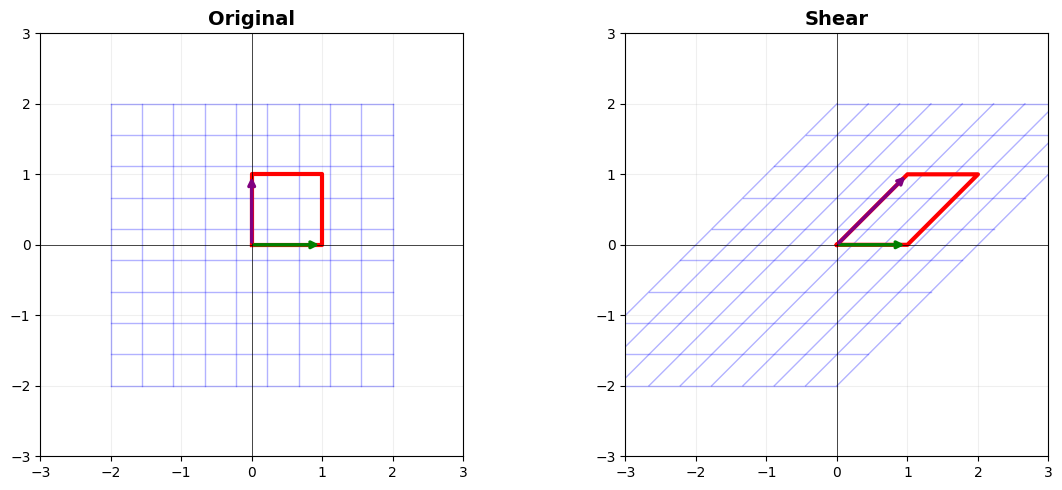

In [8]:
# 🔥 SHEAR — lean it sideways!
plot_transformation([[1, 1], [0, 1]], "Shear")

In [9]:
def mat_mul_slow(A, B):
    rowsA, colsA = A.shape
    rowsB, colsB = B.shape
    C = torch.zeros(rowsA, colsB)
    for i in range (rowsA):
        for j in range(colsB):
            for k in range(colsA):
                C[i][j] += A[i][k] * B[k][j]
    return C

size = 100
A = torch.randn(size, size)
B = torch.randn(size, size)

start_slow = time.time()
C_slow = mat_mul_slow(A, B)
slow_time = time.time() - start_slow

start_fast = time.time()
C_fast = A @ B
fast_time = time.time() - start_fast

print(f"time taken by trad mat_mul: {slow_time:.3f}sec vs time taken by pytorch: {fast_time:.6f}sec for 100x100 matrices")

time taken by trad mat_mul: 22.861sec vs time taken by pytorch: 0.009803sec for 100x100 matrices


In [10]:
print("--- Manual ---")
w_manual = 0.5
b_manual = 0.3
lr = 0.01
x_val = 2.0
target_val = 3.0

y_val = w_manual * x_val + b_manual
loss_manual = (y_val - target_val) ** 2
dL_dy = 2 * (y_val - target_val)
dy_dw = x_val
dy_db = 1.0
dL_dw = dL_dy * dy_dw
dL_db = dL_dy * dy_db

w_manual -= lr * dL_dw
b_manual -= lr * dL_db

print(f"  Loss: {loss_manual:.4f}")
print(f"  dL/dw = {dL_dw:.4f}")
print(f"  dL/db = {dL_db:.4f}")
print(f"  Updated w: {w_manual:.4f}")
print(f"  Updated b: {b_manual:.4f}")
print()

print("--- Autograd ---")
W = torch.tensor(0.5, requires_grad=True)
B = torch.tensor(0.3, requires_grad=True)
x_t = torch.tensor(2.0)
target_t = torch.tensor(3.0)

y = W * x_t + B
loss = (y - target_t) ** 2

loss.backward()
with torch.no_grad():
    W -= lr * W.grad
    B -= lr * B.grad

print(f"  Loss: {loss.item():.4f}")
print(f"  dL/dw = {W.grad.item():.4f}")
print(f"  dL/db = {B.grad.item():.4f}")
print(f"  Updated w: {W.item():.4f}")
print(f"  Updated b: {B.item():.4f}")
print()


--- Manual ---
  Loss: 2.8900
  dL/dw = -6.8000
  dL/db = -3.4000
  Updated w: 0.5680
  Updated b: 0.3340

--- Autograd ---
  Loss: 2.8900
  dL/dw = -6.8000
  dL/db = -3.4000
  Updated w: 0.5680
  Updated b: 0.3340



In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Download and prepare MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000)

print(f"Training images: {len(train_data)}")
print(f"Test images: {len(test_data)}")
print(f"Image shape: {train_data[0][0].shape} (1 channel, 28×28 pixels)")

Training images: 60000
Test images: 10000
Image shape: torch.Size([1, 28, 28]) (1 channel, 28×28 pixels)


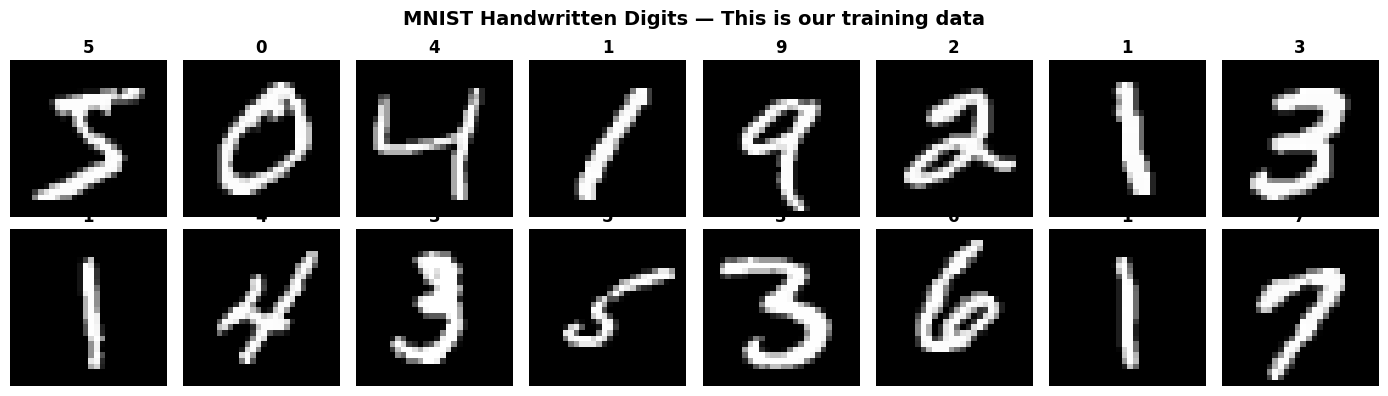

In [12]:
# Let's SEE some digits
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_data[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.axis('off')
plt.suptitle('MNIST Handwritten Digits — This is our training data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
class digit_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(784, 256)
        self.layer2 = nn.Linear(256, 128)
        self.layer3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = digit_classifier().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"  layer1: 784×256 matrix + 256 bias = {784*256 + 256:,} params")
print(f"  layer2: 256×128 matrix + 128 bias = {256*128 + 128:,} params")
print(f"  layer3: 128×10  matrix + 10  bias = {128*10 + 10:,} params")
print(f"\nAll parameters are MATRICES (+ biases).")
print(f"Training = finding the right transformations.")
print(f"Device: {device}")

Model architecture:
digit_classifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layer1): Linear(in_features=784, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=128, bias=True)
  (layer3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)

Total trainable parameters: 235,146
  layer1: 784×256 matrix + 256 bias = 200,960 params
  layer2: 256×128 matrix + 128 bias = 32,896 params
  layer3: 128×10  matrix + 10  bias = 1,290 params

All parameters are MATRICES (+ biases).
Training = finding the right transformations.
Device: cpu


In [14]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

train_losses = []
train_accs = []
test_accs = []

print("\n🔥 TRAINING STARTS NOW!\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8} | {'Time':>6}")
print("-" * 55)

for epoch in range(5):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    start = time.time()

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        predictions = model(batch_x)
        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        correct += (predictions.argmax(1) == batch_y).sum().item()
        total += len(batch_y)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            correct += (preds.argmax(1) == batch_y).sum().item()
            total += len(batch_y)
        test_acc = correct / total
        elapsed = time.time() - start

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"  {epoch+1:>3}  | {train_loss:>10.4f} | {train_acc:>8.1%} | {test_acc:>7.1%} | {elapsed:>5.1f}s")

print(f"\n🎉 Final test accuracy: {test_accs[-1]:.1%}")
print(f"   The model learned to recognize handwritten digits!")


🔥 TRAINING STARTS NOW!

Epoch | Train Loss | Train Acc | Test Acc |   Time
-------------------------------------------------------
    1  |     0.2288 |    93.1% |   96.7% |  18.8s
    2  |     0.0935 |    97.1% |   97.4% |  20.3s
    3  |     0.0664 |    97.9% |   97.4% |  18.6s
    4  |     0.0480 |    98.5% |   97.0% |  19.4s
    5  |     0.0390 |    98.7% |   97.7% |  17.6s

🎉 Final test accuracy: 97.7%
   The model learned to recognize handwritten digits!


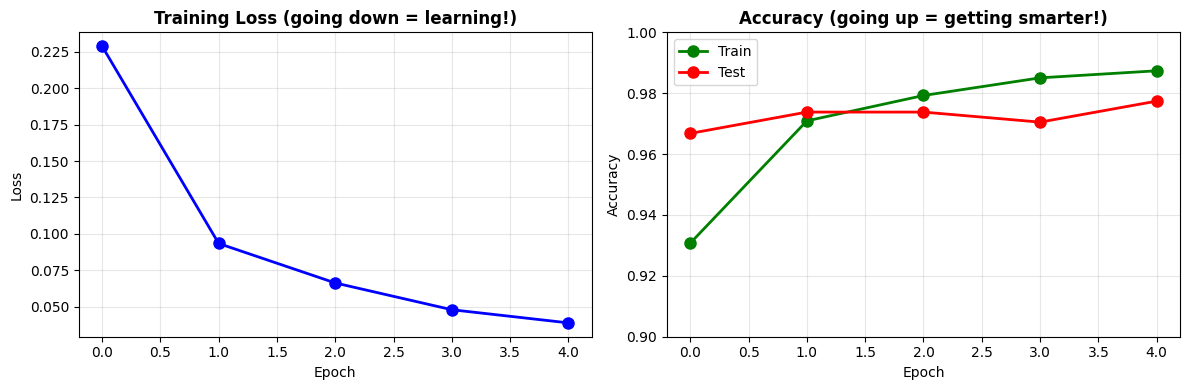

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (going down = learning!)', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, 'g-o', linewidth=2, markersize=8, label='Train')
axes[1].plot(test_accs, 'r-o', linewidth=2, markersize=8, label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy (going up = getting smarter!)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.9, 1.0)

plt.tight_layout()
plt.show()

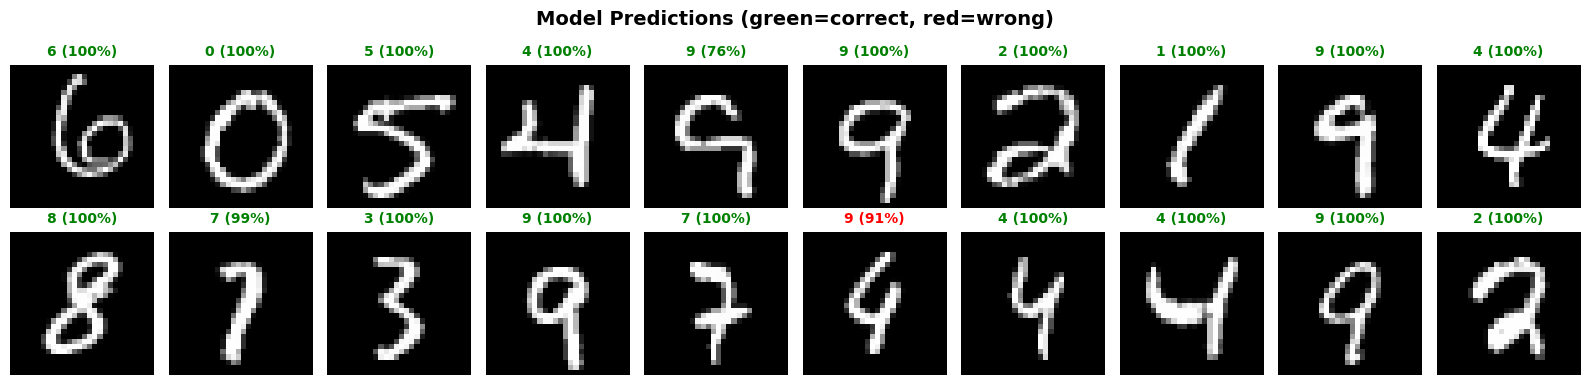

☝️ The model learned THREE matrix transformations that convert
   pixel values → digit predictions with ~97% accuracy.
   That's deep learning. That's what you built today. 🔥


In [16]:
model.eval()
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

with torch.no_grad():
    for i, ax in enumerate(axes.flat):
        img, true_label = test_data[i + 100]
        pred = model(img.unsqueeze(0).to(device))
        pred_label = pred.argmax(1).item()
        confidence = torch.softmax(pred, dim=1).max().item()

        ax.imshow(img.squeeze(), cmap='gray')
        color = 'green' if pred_label == true_label else 'red'
        ax.set_title(f'{pred_label} ({confidence:.0%})', color=color, fontsize=10, fontweight='bold')
        ax.axis('off')

plt.suptitle('Model Predictions (green=correct, red=wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("☝️ The model learned THREE matrix transformations that convert")
print("   pixel values → digit predictions with ~97% accuracy.")
print("   That's deep learning. That's what you built today. 🔥")

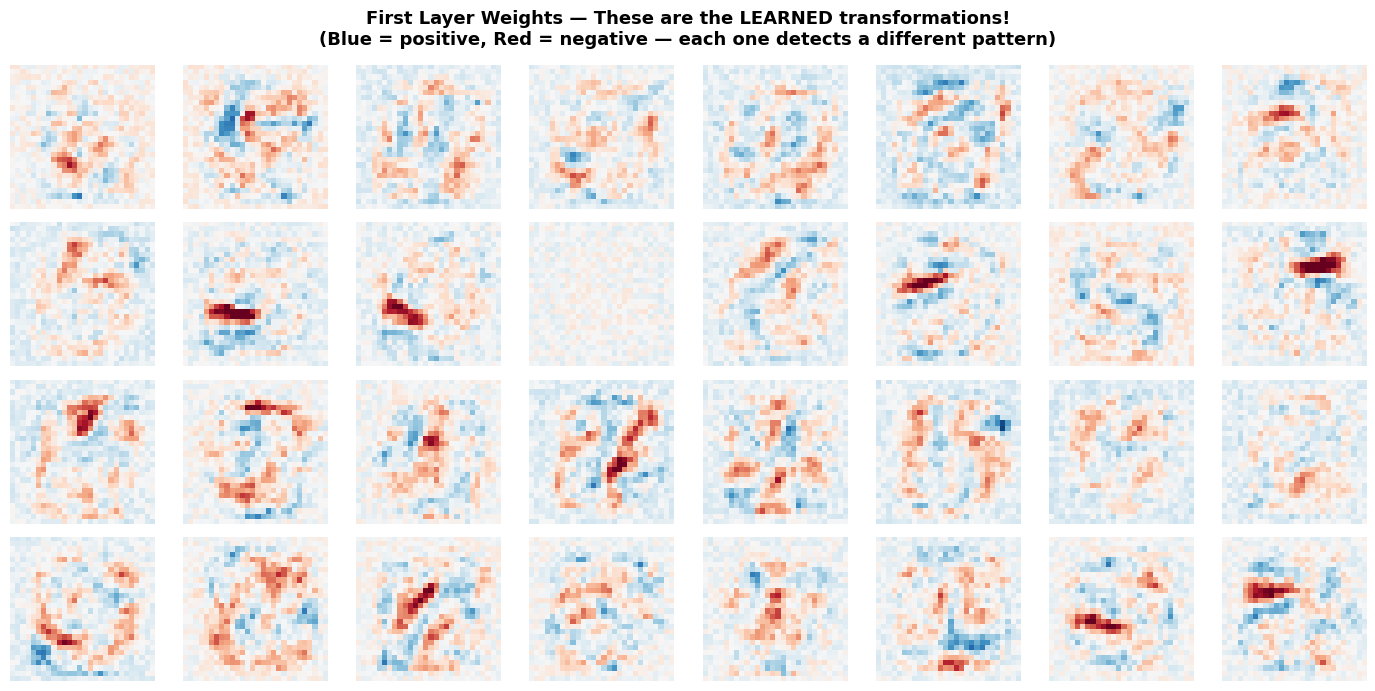

Each of these 28×28 grids is a ROW of the first weight matrix.
The model learned these patterns automatically through training.
Some look like edges, curves, or digit fragments.
This is what 'learned transformation' actually looks like!


In [17]:
weights = model.layer1.weight.data.cpu()

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    w = weights[i].reshape(28, 28)
    ax.imshow(w, cmap='RdBu', vmin=-0.3, vmax=0.3)
    ax.axis('off')

plt.suptitle('First Layer Weights — These are the LEARNED transformations!\n'
             '(Blue = positive, Red = negative — each one detects a different pattern)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each of these 28×28 grids is a ROW of the first weight matrix.")
print("The model learned these patterns automatically through training.")
print("Some look like edges, curves, or digit fragments.")
print("This is what 'learned transformation' actually looks like!")